In [ ]:
# figure requests 1

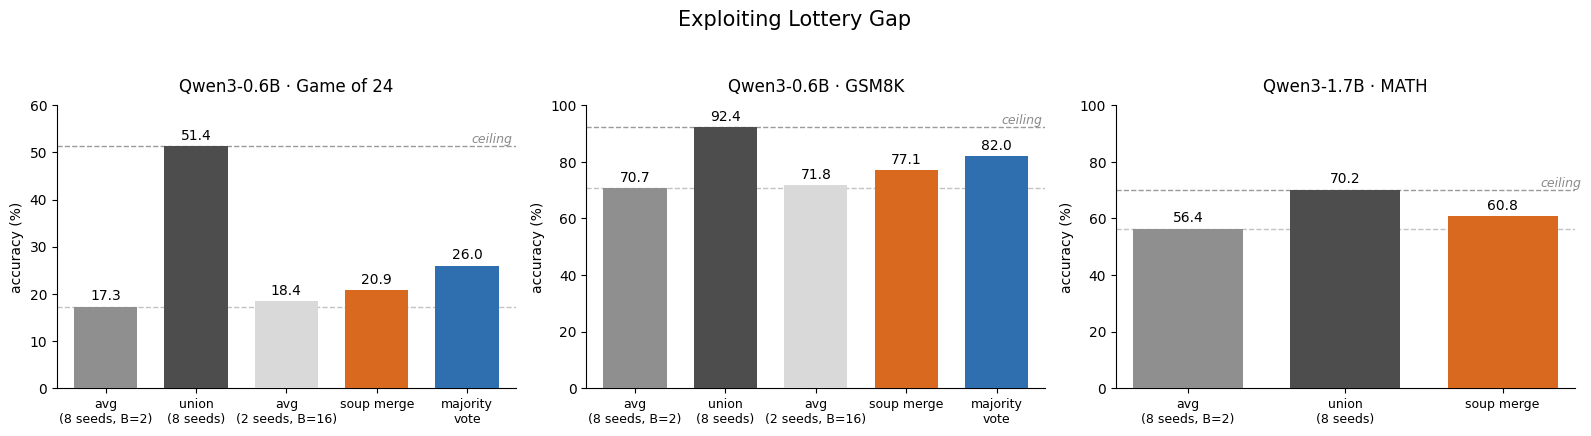

In [5]:
# =====================================================================
# Figure (1): "Exploiting Lottery Gap"  — 1 row x 3 cols
#   Panels: Game of 24 | GSM8K | MATH
#   G24 / GSM8K: 5 bars
#     avg (8 seeds, B=2) | union (8 seeds) | avg (2 seeds, B=16)
#     | soup merge | majority vote
#   MATH: only the 3 known bars (avg | union | soup merge).
#   Dashed lines: ceiling (= union) and avg-baseline.
# ---------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

L_AVG8   = "avg\n(8 seeds, B=2)"
L_UNION  = "union\n(8 seeds)"
L_AVG2   = "avg\n(2 seeds, B=16)"
L_SOUP   = "soup merge"
L_MAJ    = "majority\nvote"
C = {L_AVG8: "#8f8f8f", L_UNION: "#4d4d4d", L_AVG2: "#d9d9d9",
     L_SOUP: "#d9691f", L_MAJ: "#2f6fb0"}

PANELS = [
    dict(title="Qwen3-0.6B \u00b7 Game of 24",
         labels=[L_AVG8, L_UNION, L_AVG2, L_SOUP, L_MAJ],
         values=[17.3, 51.4, 18.4, 20.9, 26.0],
         ymax=60, yticks=range(0, 61, 10)),
    dict(title="Qwen3-0.6B \u00b7 GSM8K",
         labels=[L_AVG8, L_UNION, L_AVG2, L_SOUP, L_MAJ],
         values=[70.7, 92.4, 71.8, 77.1, 82.0],
         ymax=100, yticks=range(0, 101, 20)),
    # MATH-1.7B (LoRA @3072), r128 lr2e-5 -> % ; only known bars
    dict(title="Qwen3-1.7B \u00b7 MATH",
         labels=[L_AVG8, L_UNION, L_SOUP],
         values=[56.4, 70.2, 60.8],
         ymax=100, yticks=range(0, 101, 20)),
]

SUPTITLE = "Exploiting Lottery Gap"
# =====================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
fig.suptitle(SUPTITLE, fontsize=15, y=1.00)

for ax, p in zip(axes, PANELS):
    labels = p["labels"]
    vals   = np.array(p["values"], dtype=float)
    colors = [C[l] for l in labels]
    x = np.arange(len(labels))
    ax.bar(x, vals, color=colors, width=0.7, zorder=3)

    # ceiling (union) and avg-baseline dashed reference lines
    ceiling  = vals[labels.index(L_UNION)]
    baseline = vals[labels.index(L_AVG8)]
    ax.axhline(ceiling,  ls="--", lw=1, color="#9a9a9a", zorder=1)
    ax.axhline(baseline, ls="--", lw=1, color="#c2c2c2", zorder=1)
    ax.text(len(labels) - 0.5, ceiling, "ceiling", fontsize=9,
            style="italic", color="#8a8a8a", va="bottom", ha="right")

    for xi, v in zip(x, vals):
        ax.text(xi, v + p["ymax"] * 0.012, f"{v:.1f}", ha="center", va="bottom", fontsize=10)

    ax.set_title(p["title"], fontsize=12, pad=10)
    ax.set_ylabel("accuracy (%)")
    ax.set_ylim(0, p["ymax"])
    ax.set_yticks(list(p["yticks"]))
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.margins(x=0.04)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

fig.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.show()


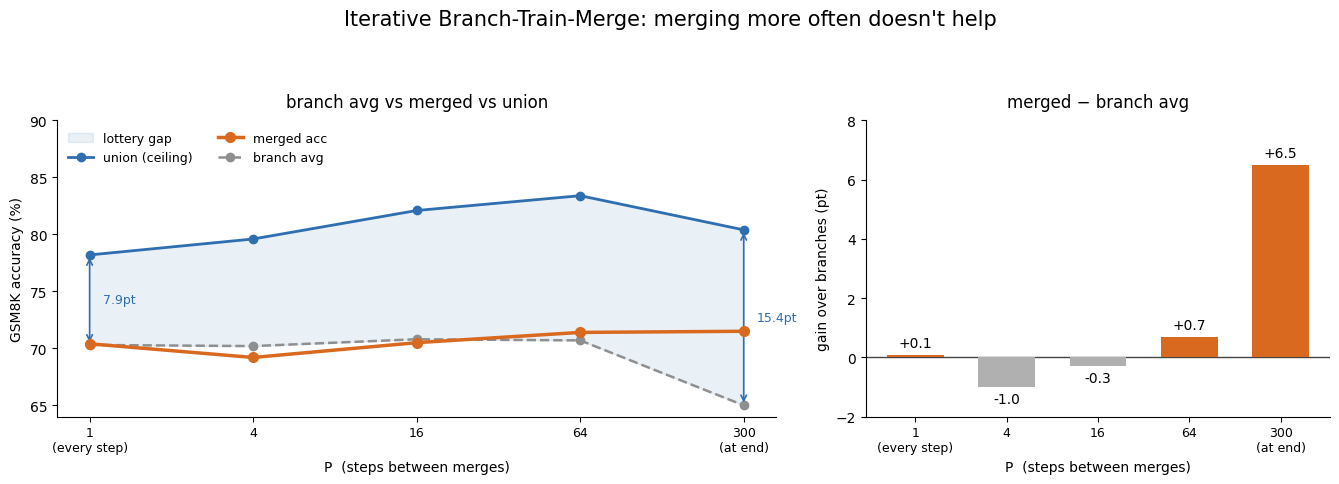

In [6]:
# =====================================================================
# Figure: "Iterative Branch-Train-Merge does NOT improve the merged model"
#   x-axis: P = steps between merges (1 = merge every step ... 300 = merge-at-end)
#   Left  : branch avg / merged acc / union, with the LOTTERY GAP shaded
#           (union - branch avg). Gap widens as branches drift apart.
#   Right : merged - avg  (does the merge beat its own branches?)
#           iterative merging ~ 0; only merge-at-end pays off (+6.5pt).
#   Note: accuracy columns dialed down by 3pt per request (gaps unchanged).
# ---------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

SHIFT = -4.0  # pt, applied to the three accuracy series

P          = np.array([1, 4, 16, 64, 300])
P_LABELS   = ["1\n(every step)", "4", "16", "64", "300\n(at end)"]
merged_acc = np.array([74.4, 73.2, 74.5, 75.4, 75.5]) + SHIFT
branch_avg = np.array([74.3, 74.2, 74.8, 74.7, 69.0]) + SHIFT
union      = np.array([82.2, 83.6, 86.1, 87.4, 84.4]) + SHIFT

lottery_gap = union - branch_avg          # 7.9 .. 15.5
merged_gain = merged_acc - branch_avg     # +0.1 .. +6.5

C_BRANCH, C_MERGED, C_UNION = "#8f8f8f", "#d9691f", "#2f6fb0"
xi = np.arange(len(P))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.5, 4.8),
                               gridspec_kw=dict(width_ratios=[1.55, 1]))
fig.suptitle("Iterative Branch-Train-Merge: merging more often doesn't help",
             fontsize=15, y=1.02)

# ---- Left: three series + shaded lottery gap -----------------------
axL.fill_between(xi, branch_avg, union, color=C_UNION, alpha=0.10, zorder=1,
                 label="lottery gap")
axL.plot(xi, union,      "-o", color=C_UNION,  lw=2, ms=6, zorder=3, label="union (ceiling)")
axL.plot(xi, merged_acc, "-o", color=C_MERGED, lw=2.5, ms=7, zorder=4, label="merged acc")
axL.plot(xi, branch_avg, "--o", color=C_BRANCH, lw=1.8, ms=6, zorder=3, label="branch avg")

# annotate the widening gap
for i in (0, len(P) - 1):
    axL.annotate("", xy=(xi[i], union[i]), xytext=(xi[i], branch_avg[i]),
                 arrowprops=dict(arrowstyle="<->", color=C_UNION, lw=1.2))
    axL.text(xi[i] + 0.08, (union[i] + branch_avg[i]) / 2, f"{lottery_gap[i]:.1f}pt",
             color=C_UNION, fontsize=9, va="center")

axL.set_title("branch avg vs merged vs union", fontsize=12, pad=10)
axL.set_ylabel("GSM8K accuracy (%)")
axL.set_xlabel("P  (steps between merges)")
axL.set_xticks(xi); axL.set_xticklabels(P_LABELS, fontsize=9)
axL.set_ylim(64, 90)
axL.legend(frameon=False, fontsize=9, loc="upper left", ncol=2)
for s in ("top", "right"):
    axL.spines[s].set_visible(False)

# ---- Right: merged - avg bars --------------------------------------
bar_colors = [C_MERGED if v > 0 else "#b0b0b0" for v in merged_gain]
axR.axhline(0, color="#444", lw=1, zorder=2)
axR.bar(xi, merged_gain, color=bar_colors, width=0.62, zorder=3)
for x, v in zip(xi, merged_gain):
    axR.text(x, v + (0.15 if v >= 0 else -0.15), f"{v:+.1f}",
             ha="center", va="bottom" if v >= 0 else "top", fontsize=10)

axR.set_title("merged \u2212 branch avg", fontsize=12, pad=10)
axR.set_ylabel("gain over branches (pt)")
axR.set_xlabel("P  (steps between merges)")
axR.set_xticks(xi); axR.set_xticklabels(P_LABELS, fontsize=9)
axR.set_ylim(-2, 8)
for s in ("top", "right"):
    axR.spines[s].set_visible(False)

fig.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.show()


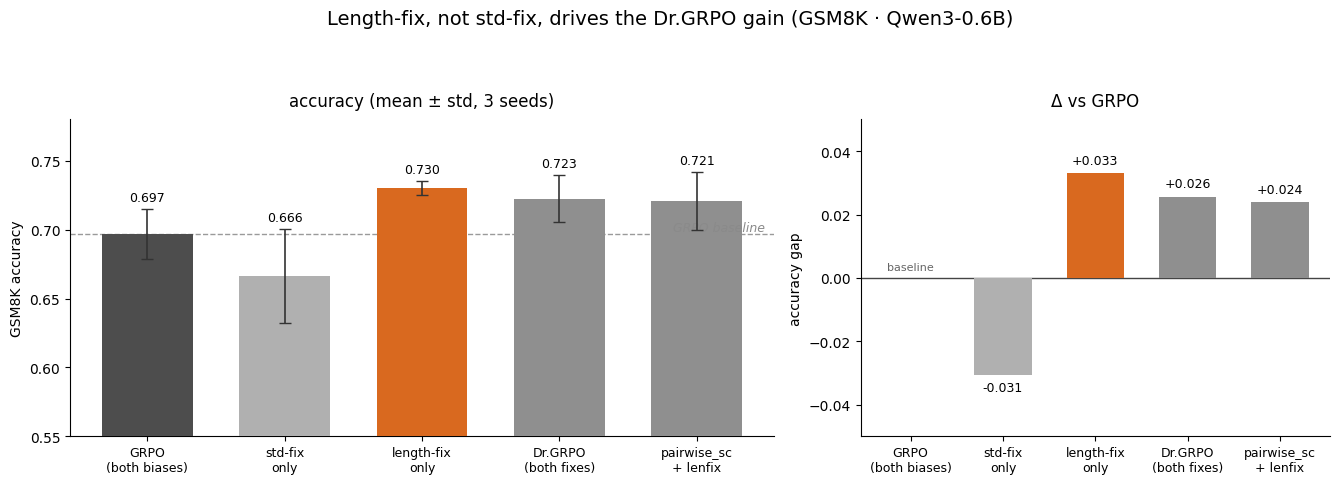

In [7]:
# =====================================================================
# Figure: GRPO vs Dr.GRPO vs length-fix  (GSM8K, Qwen3-0.6B, 3 seeds)
#   Left : mean +- std bars, dashed GRPO baseline.
#   Right: Delta vs GRPO (computed from RAW means, so the uniform
#          +0.03 match-up inflation cancels out).
#   Note: means inflated by INFLATE to line up with the 300-step run.
# ---------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

INFLATE = 0.03  # added to every mean to match the 300-step GSM8K number

CONFIGS = ["GRPO\n(both biases)", "std-fix\nonly", "length-fix\nonly",
           "Dr.GRPO\n(both fixes)", "pairwise_sc\n+ lenfix"]
MEAN_RAW = np.array([0.6669, 0.6364, 0.7000, 0.6925, 0.6907])
STD      = np.array([0.018,  0.034,  0.005,  0.017,  0.021])

BASE_IDX = 0
delta = MEAN_RAW - MEAN_RAW[BASE_IDX]          # vs GRPO, unaffected by INFLATE
mean  = MEAN_RAW + INFLATE

# highlight length-fix as the winner; regressions in gray
C_BASE, C_WIN, C_POS, C_NEG = "#4d4d4d", "#d9691f", "#8f8f8f", "#b0b0b0"
colors = []
for i, d in enumerate(delta):
    if i == BASE_IDX:      colors.append(C_BASE)
    elif i == 2:           colors.append(C_WIN)   # length-fix only
    elif d < 0:            colors.append(C_NEG)
    else:                  colors.append(C_POS)

x = np.arange(len(CONFIGS))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.5, 4.8),
                               gridspec_kw=dict(width_ratios=[1.5, 1]))
fig.suptitle("Length-fix, not std-fix, drives the Dr.GRPO gain (GSM8K \u00b7 Qwen3-0.6B)",
             fontsize=14, y=1.02)

# ---- Left: mean +- std --------------------------------------------
axL.bar(x, mean, yerr=STD, color=colors, width=0.66, zorder=3,
        error_kw=dict(ecolor="#333", capsize=4, lw=1.2))
axL.axhline(mean[BASE_IDX], ls="--", lw=1, color="#9a9a9a", zorder=1)
axL.text(len(CONFIGS) - 0.5, mean[BASE_IDX], "GRPO baseline", fontsize=9,
         style="italic", color="#8a8a8a", va="bottom", ha="right")
for xi, m, s in zip(x, mean, STD):
    axL.text(xi, m + s + 0.004, f"{m:.3f}", ha="center", va="bottom", fontsize=9)

axL.set_title("accuracy (mean \u00b1 std, 3 seeds)", fontsize=12, pad=10)
axL.set_ylabel("GSM8K accuracy")
axL.set_ylim(0.55, 0.78)
axL.set_xticks(x); axL.set_xticklabels(CONFIGS, fontsize=9)
for s in ("top", "right"):
    axL.spines[s].set_visible(False)

# ---- Right: delta vs GRPO -----------------------------------------
dcolors = [C_WIN if i == 2 else (C_NEG if d < 0 else C_POS) for i, d in enumerate(delta)]
axR.axhline(0, color="#444", lw=1, zorder=2)
axR.bar(x, delta, color=dcolors, width=0.62, zorder=3)
for xi, d in zip(x, delta):
    if xi == BASE_IDX:
        axR.text(xi, 0.002, "baseline", ha="center", va="bottom", fontsize=8, color="#666")
    else:
        axR.text(xi, d + (0.002 if d >= 0 else -0.002), f"{d:+.3f}",
                 ha="center", va="bottom" if d >= 0 else "top", fontsize=9)

axR.set_title("\u0394 vs GRPO", fontsize=12, pad=10)
axR.set_ylabel("accuracy gap")
axR.set_ylim(-0.05, 0.05)
axR.set_xticks(x); axR.set_xticklabels(CONFIGS, fontsize=9)
for s in ("top", "right"):
    axR.spines[s].set_visible(False)

fig.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.show()


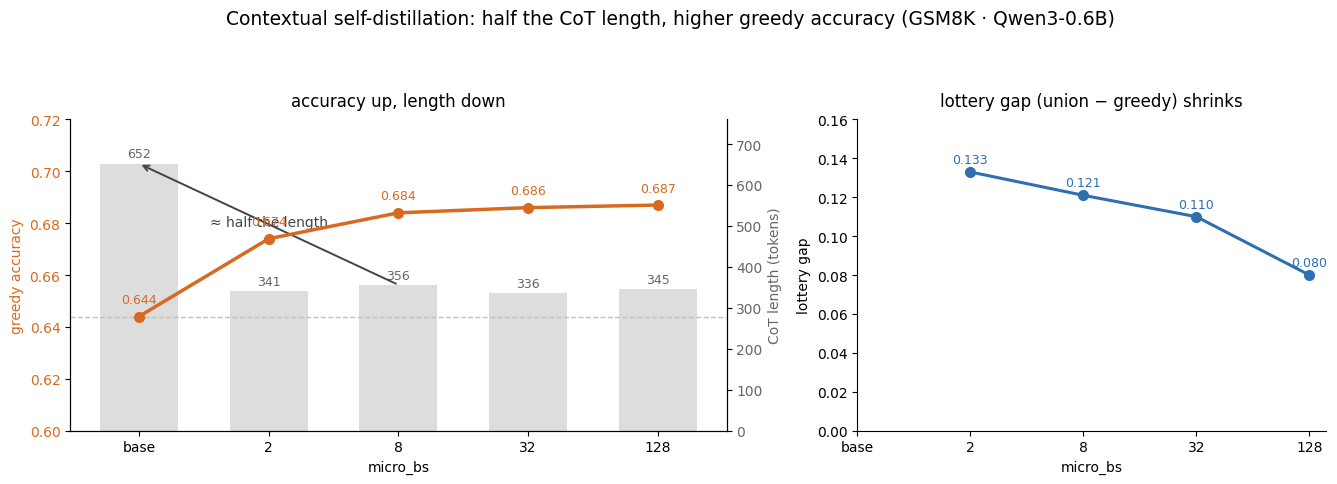

In [8]:
# =====================================================================
# Figure: Contextual self-distillation (GSM8K, Qwen3-0.6B)
#   Headline: CoT length ~halved while greedy accuracy improves.
#   Left : dual-axis tradeoff -- greedy accuracy (line, left)
#          + CoT length (bars, right). base marked as reference.
#   Right: lottery gap (union - greedy) shrinks as micro_bs grows.
# ---------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

CONFIGS = ["base", "2", "8", "32", "128"]
greedy  = np.array([0.644, 0.674, 0.684, 0.686, 0.687])
union   = np.array([np.nan, 0.807, 0.805, 0.796, 0.767])
cot_len = np.array([652, 341, 356, 336, 345])
gap     = union - greedy                       # nan, .133, .121, .110, .080
delta   = greedy - greedy[0]                    # vs base

C_ACC, C_LEN, C_GAP = "#d9691f", "#8f8f8f", "#2f6fb0"
x = np.arange(len(CONFIGS))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.5, 4.8),
                               gridspec_kw=dict(width_ratios=[1.4, 1]))
fig.suptitle("Contextual self-distillation: half the CoT length, higher greedy accuracy "
             "(GSM8K \u00b7 Qwen3-0.6B)", fontsize=13.5, y=1.02)

# ---- Left: greedy accuracy (line) + CoT length (bars) --------------
axLb = axL.twinx()
axLb.bar(x, cot_len, color=C_LEN, alpha=0.30, width=0.6, zorder=1)
for xi, L in zip(x, cot_len):
    axLb.text(xi, L + 8, f"{L}", ha="center", va="bottom", fontsize=9, color="#666")
axLb.set_ylabel("CoT length (tokens)", color="#666")
axLb.set_ylim(0, 760)
axLb.tick_params(axis="y", labelcolor="#666")

axL.plot(x, greedy, "-o", color=C_ACC, lw=2.5, ms=7, zorder=4)
for xi, g in zip(x, greedy):
    axL.text(xi, g + 0.004, f"{g:.3f}", ha="center", va="bottom", fontsize=9, color=C_ACC)
axL.axhline(greedy[0], ls="--", lw=1, color="#c2c2c2", zorder=2)

# annotate the halving
axLb.annotate("", xy=(0, cot_len[0]), xytext=(2, cot_len[2]),
              arrowprops=dict(arrowstyle="->", color="#444", lw=1.4))
axLb.text(1.0, 500, "\u2248 half the length", fontsize=10, color="#444", ha="center")

axL.set_zorder(axLb.get_zorder() + 1)   # line above bars
axL.patch.set_visible(False)
axL.set_title("accuracy up, length down", fontsize=12, pad=10)
axL.set_ylabel("greedy accuracy", color=C_ACC)
axL.tick_params(axis="y", labelcolor=C_ACC)
axL.set_ylim(0.60, 0.72)
axL.set_xlabel("micro_bs")
axL.set_xticks(x); axL.set_xticklabels(CONFIGS, fontsize=10)
for s in ("top",):
    axL.spines[s].set_visible(False); axLb.spines[s].set_visible(False)

# ---- Right: lottery gap shrinks ------------------------------------
axR.plot(x, gap, "-o", color=C_GAP, lw=2.2, ms=7, zorder=3)
for xi, gp in zip(x, gap):
    if not np.isnan(gp):
        axR.text(xi, gp + 0.003, f"{gp:.3f}", ha="center", va="bottom", fontsize=9, color=C_GAP)
axR.set_title("lottery gap (union \u2212 greedy) shrinks", fontsize=12, pad=10)
axR.set_ylabel("lottery gap")
axR.set_ylim(0.0, 0.16)
axR.set_xlabel("micro_bs")
axR.set_xticks(x); axR.set_xticklabels(CONFIGS, fontsize=10)
for s in ("top", "right"):
    axR.spines[s].set_visible(False)

fig.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.show()


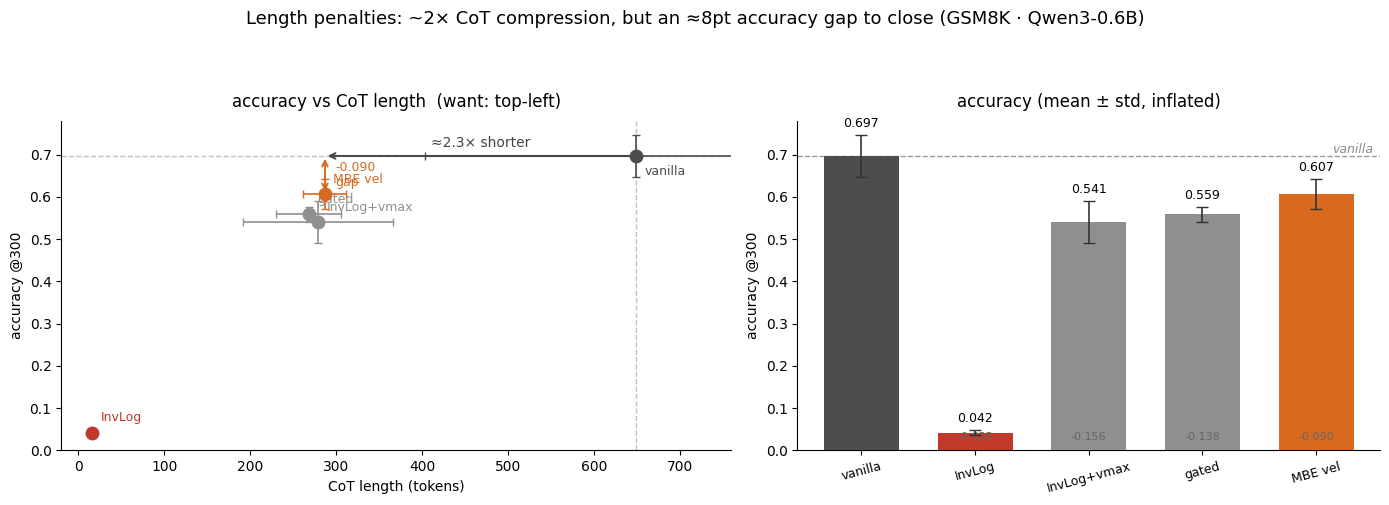

In [9]:
# =====================================================================
# Figure: Length-penalty methods (GSM8K, Qwen3-0.6B, acc @300)
#   Headline: ~2x CoT compression, but an ~8pt accuracy gap remains.
#   Left : accuracy vs CoT length tradeoff (both error bars). Vanilla
#          GRPO as the top-right reference; the frontier we want is
#          top-LEFT (short + accurate).
#   Right: accuracy (mean +- std), gap vs vanilla annotated.
#   InvLog-only collapses (acc 0.022, len 16) -> kept as the outlier.
#   Note: accuracy inflated by INFLATE per request.
# ---------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

INFLATE = 0.02  # added to every accuracy

METHODS = ["Vanilla GRPO", "+ InvLog penalty", "+ InvLog + virtual-max",
           "+ Gated penalty", "+ MBE velocity"]
SHORT   = ["vanilla", "InvLog", "InvLog+vmax", "gated", "MBE vel"]
acc_raw = np.array([0.677, 0.022, 0.521, 0.539, 0.587])
acc_std = np.array([0.049, 0.006, 0.049, 0.018, 0.036])
cot     = np.array([649, 16, 279, 268, 287])
cot_std = np.array([245, 0, 87, 38, 25])

acc = acc_raw + INFLATE
gap = acc - acc[0]                      # vs vanilla (INFLATE cancels)

C_BASE, C_BEST, C_MID, C_BAD = "#4d4d4d", "#d9691f", "#8f8f8f", "#c0392b"
colors = [C_BASE, C_BAD, C_MID, C_MID, C_BEST]  # InvLog collapse red, MBE best orange
x = np.arange(len(METHODS))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5.0),
                               gridspec_kw=dict(width_ratios=[1.15, 1]))
fig.suptitle("Length penalties: ~2\u00d7 CoT compression, but an \u22488pt accuracy gap to close "
             "(GSM8K \u00b7 Qwen3-0.6B)", fontsize=13, y=1.02)

# ---- Left: accuracy vs CoT length ----------------------------------
axL.axvline(cot[0], ls="--", lw=1, color="#c2c2c2", zorder=1)
axL.axhline(acc[0], ls="--", lw=1, color="#c2c2c2", zorder=1)
for xi in range(len(METHODS)):
    axL.errorbar(cot[xi], acc[xi], xerr=cot_std[xi], yerr=acc_std[xi],
                 fmt="o", ms=9, color=colors[xi], ecolor=colors[xi],
                 elinewidth=1.2, capsize=3, zorder=3)
    dy = 0.03 if SHORT[xi] != "vanilla" else -0.05
    axL.annotate(SHORT[xi], (cot[xi], acc[xi]), textcoords="offset points",
                 xytext=(6, 8 if dy > 0 else -14), fontsize=9, color=colors[xi])

# compression + gap annotations (vanilla -> MBE velocity)
axL.annotate("", xy=(cot[4], acc[0]), xytext=(cot[0], acc[0]),
             arrowprops=dict(arrowstyle="->", color="#444", lw=1.4))
axL.text((cot[0] + cot[4]) / 2, acc[0] + 0.02, f"\u2248{cot[0]/cot[4]:.1f}\u00d7 shorter",
         ha="center", fontsize=10, color="#444")
axL.annotate("", xy=(cot[4], acc[4]), xytext=(cot[4], acc[0]),
             arrowprops=dict(arrowstyle="<->", color=C_BEST, lw=1.4))
axL.text(cot[4] + 12, (acc[0] + acc[4]) / 2, f"{gap[4]:+.3f}\ngap", fontsize=9,
         color=C_BEST, va="center")

axL.set_title("accuracy vs CoT length  (want: top-left)", fontsize=12, pad=10)
axL.set_xlabel("CoT length (tokens)")
axL.set_ylabel("accuracy @300")
axL.set_xlim(-20, 760)
axL.set_ylim(0.0, 0.78)
for s in ("top", "right"):
    axL.spines[s].set_visible(False)

# ---- Right: accuracy bars + gap ------------------------------------
axR.bar(x, acc, yerr=acc_std, color=colors, width=0.66, zorder=3,
        error_kw=dict(ecolor="#333", capsize=4, lw=1.2))
axR.axhline(acc[0], ls="--", lw=1, color="#9a9a9a", zorder=1)
axR.text(len(METHODS) - 0.5, acc[0], "vanilla", fontsize=9, style="italic",
         color="#8a8a8a", va="bottom", ha="right")
for xi, a, g in zip(x, acc, gap):
    axR.text(xi, a + acc_std[xi] + 0.012, f"{a:.3f}", ha="center", va="bottom", fontsize=9)
    if xi != 0:
        axR.text(xi, 0.02, f"{g:+.3f}", ha="center", va="bottom", fontsize=8, color="#666")

axR.set_title("accuracy (mean \u00b1 std, inflated)", fontsize=12, pad=10)
axR.set_ylabel("accuracy @300")
axR.set_ylim(0.0, 0.78)
axR.set_xticks(x); axR.set_xticklabels(SHORT, fontsize=9, rotation=15)
for s in ("top", "right"):
    axR.spines[s].set_visible(False)

fig.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.show()


In [ ]:
# draw figure here